# Visión por Computadora I - Trabajo Práctico N°2

### Goal:
Implementation of a maximum focus detector over a video, via spectral analysis techniques that are similar to those used in modern digital cameras.
VIdeo to process is:s: “focus_video.mov”

Implement an algorithm that, given an image or image region, calculates the metric poposed in “[Image Sharpness Measure for Blurred Images in Frequency Domain](https://doi.org/10.1016/j.proeng.2013.09.086)”. a2 experiments must be donent    os:Measure over the whole framefr    ameMeasure over a ROI placed at the frame's centre. Area of the region should be around 5% or 10% of the whole frame's area.f

For each of these, one or multiple curves must be displayed, that show the evolution of the metric frame to frame, and where it's clearly shown where the maximum focus point (frame) is. 

The detection algorithm must detect and return the maximum focus points (frames) automatically. 

**Extra points**: Use unsharp masking to extend the focus zone. y devolver.

### Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

## Focus Detection

In [2]:
# First, lets define the metric that the paper suggest.
def image_quality_measure(img, threshold_factor=1e-3):
    # Get shape
    img_h, img_w = img.shape[:2]
    # Get modulus of the zero centered Fourier transform
    F_modulus = np.abs(
        np.fft.fftshift(np.fft.fft2(img))
    )
    # Get its maximum
    F_modulus_max = np.max(F_modulus)
    # Get number of pixels above threshold.
    T_H = np.sum(F_modulus > (F_modulus_max*threshold_factor))

    return T_H / (img_h*img_w)

In [3]:
# Second, let's code a way to extract the square at the center of the img.
def get_roi(img, percentage=0.1):
    # Get shape
    img_h, img_w = img.shape[:2]
    # Get target num pixels = percent * total num pixels
    area = percentage * img_h * img_w 
    # Get square side length (we round to get an integer)
    l = int(np.rint(np.sqrt(area)))
    # Safety check for weird aspect ratios
    l = min(l, img_h, img_w)
    # Get sliding indices
    center_y, center_x = img_h // 2, img_w // 2
    idx_y, idx_x = center_y - l // 2, center_x - l // 2

    return img[idx_y: idx_y+l, idx_x: idx_x+l]

In [4]:
# Load vid and calculate metric for each frame
vid_path = 'focus_video.mov'
vcap = cv2.VideoCapture(vid_path)

metric, metric_roi = [], []

if vcap.isOpened():
    while True:
        # Get frame.
        ret, frame = vcap.read()
        # If error or last frame.
        if not ret:
            break
    
        # To grayscale.
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Metric over frame.
        metric_val = image_quality_measure(gray)

        # Metric over ROI.
        metric_roi_val = image_quality_measure(get_roi(gray))

        # Add values.
        metric.append(metric_val)
        metric_roi.append(metric_roi_val)
        
        # Exit on 'q' press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release and close windows.
vcap.release()
cv2.destroyAllWindows()

In [5]:
len(metric), len(metric_roi)

(171, 171)

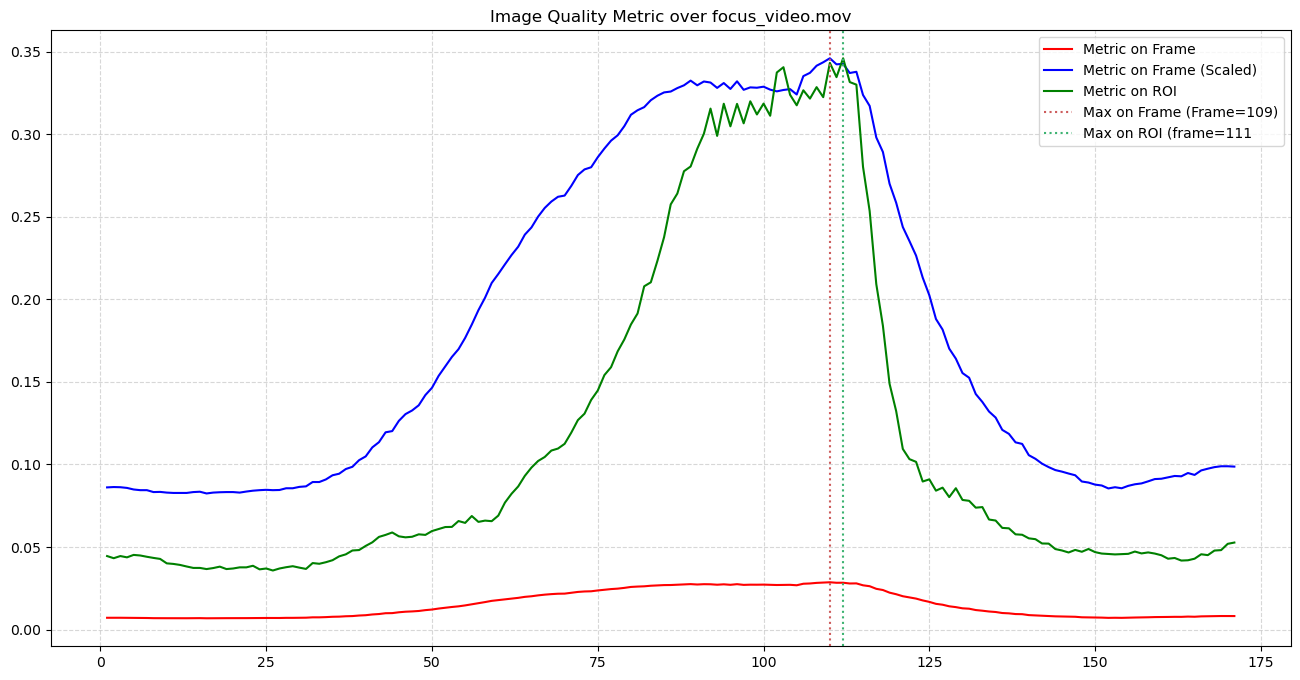

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(16, 8))

# Curves
x = np.arange(1, len(metric)+1)
ax.plot(x, metric, color='r', label='Metric on Frame')
ax.plot(x, np.array(metric)*np.max(metric_roi)/np.max(metric), color='b', label='Metric on Frame (Scaled)')
ax.plot(x, metric_roi, color='g', label='Metric on ROI')

# Max
ax.axvline(x[np.argmax(metric)], color='indianred', linestyle=":", label=f"Max on Frame (Frame={np.argmax(metric)})")
ax.axvline(x[np.argmax(metric_roi)], color='mediumseagreen', linestyle=":", label=f"Max on ROI (frame={np.argmax(metric_roi)}")

ax.set_title(f'Image Quality Metric over {vid_path}')
ax.grid(zorder=0, linestyle='--', alpha=0.5)
ax.legend()

plt.show()

Both methods seem to give the "best focused" frames around the same region. ROI method seems to give a narrower region than the whole frame method. This could be because in the original video the background seems to come into focus a some frames earlier than the object, which the ROI method doesn't quite catch. These metrics seem to disagree on which is the best focused frame, but the discrepancy is only two frames apart.

For the best focused region method we'll usee the ROI method. For this particular case the ROI method might be suitable, since the object is around the center of the video, but for other cases where the object isn't exactly centered, it may be advantageous to use the whole frame method. We'll set the focus criteria to 15 percent of the max value, while requiring the frames are consecutive (either backwards or forwards)

In [7]:
# Get which frames compose the best focused segment of the video.
def get_best_focused_segment(path, criteria=0.15):
    vcap = cv2.VideoCapture(path)
    
    metric_roi = []
    
    if vcap.isOpened():
        while True:
            # Get frame.
            ret, frame = vcap.read()
            # If error or last frame.
            if not ret:
                break
        
            # To grayscale.
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
            # Metric over ROI.
            metric_roi_val = image_quality_measure(get_roi(gray))
    
            # Add values.
            metric_roi.append(metric_roi_val)
            
            # Exit on 'q' press
            if cv2.waitKey(1) & 0xFF == ord('q'):
                return

    # Check iteration didn't end early
    frames = int(vcap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frames > len(metric_roi):
        print(frames, len(metric_roi))
        return

    # Get max value (index).
    roi_max_idx = np.argmax(metric_roi)

    # Get threshold
    thresh = (1-criteria)*metric_roi[roi_max_idx]

    # Best focused frames
    best_frames = [int(roi_max_idx)]

    # Find frames.
    next_frame_oob, prev_frame_oob = False, False
    for idx in range(1, frames):
        if not next_frame_oob:
            try:
                next_frame_val = metric_roi[roi_max_idx+idx]
                if next_frame_val > thresh:
                    best_frames.append(int(roi_max_idx+idx))
                else:
                    next_frame_oob = True
            except IndexError:
                next_frame_oob = True
        if not prev_frame_oob:
            try:
                prev_frame_val = metric_roi[roi_max_idx-idx]
                if prev_frame_val > thresh:
                    best_frames.append(int(roi_max_idx-idx))
                else:
                    prev_frame_oob = True
            except IndexError:
                prev_frame_oob = True

    return sorted(best_frames)

In [8]:
best_frames = get_best_focused_segment(vid_path)
print(best_frames)

[90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]


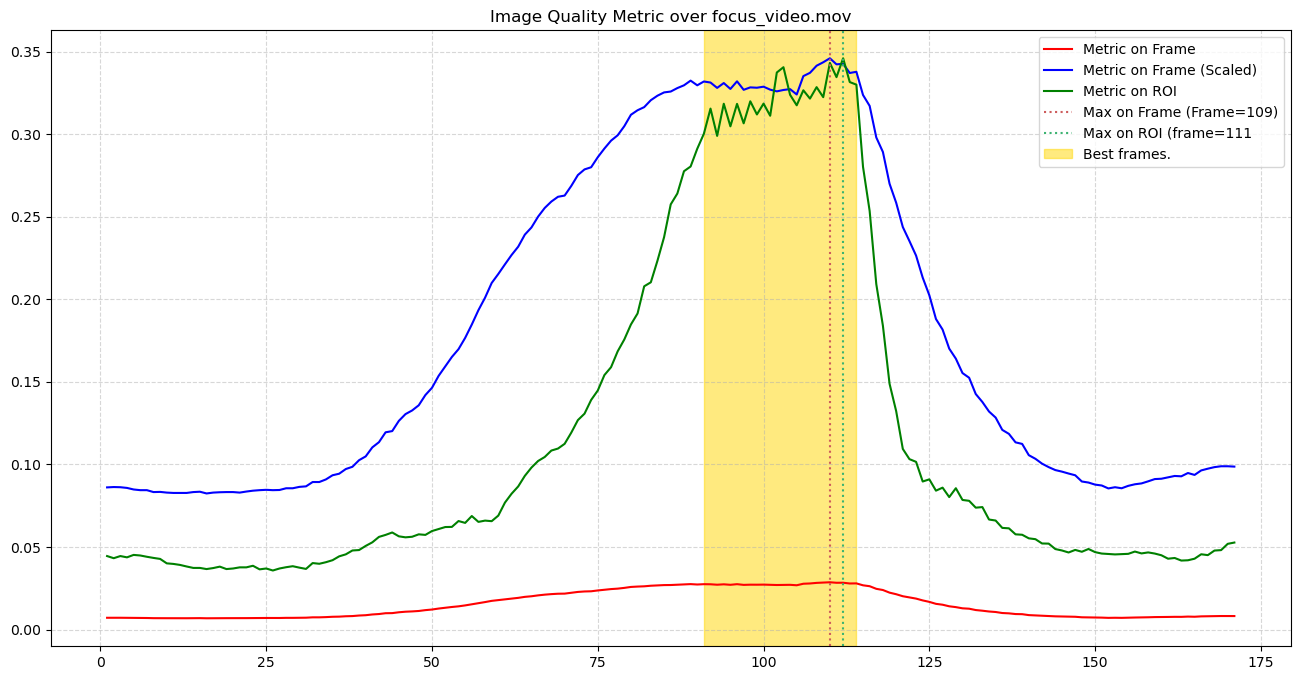

In [9]:
# Repeat graph with best frames marked
fig, ax = plt.subplots(figsize=(16, 8))

# Curves
x = np.arange(1, len(metric)+1)
ax.plot(x, metric, color='r', label='Metric on Frame')
ax.plot(x, np.array(metric)*np.max(metric_roi)/np.max(metric), color='b', label='Metric on Frame (Scaled)')
ax.plot(x, metric_roi, color='g', label='Metric on ROI')

# Max
ax.axvline(x[np.argmax(metric)], color='indianred', linestyle=":", label=f"Max on Frame (Frame={np.argmax(metric)})")
ax.axvline(x[np.argmax(metric_roi)], color='mediumseagreen', linestyle=":", label=f"Max on ROI (frame={np.argmax(metric_roi)}")

# Best frames.
ax.axvspan(best_frames[0]+1, best_frames[-1]+1, color='gold', alpha=0.5, label='Best frames.')

ax.set_title(f'Image Quality Metric over {vid_path}')
ax.grid(zorder=0, linestyle='--', alpha=0.5)
ax.legend()

plt.show()


## 2) Unsharp Masking

We'll repeat the above logic, but after getting the best frames we'll continue expanding our frame sequence using the threshold and metrics derived from a copy of the video to which unsharp masking has been applied to each frame.

In [10]:
# Define unsharp masking.
def apply_unsharp_masking(img, k, kernel_size=None, std=1):
    # Get blur
    kernel_size = 0 if kernel_size is None else kernel_size
    blur = cv2.GaussianBlur(img, (kernel_size, kernel_size), std)

    return cv2.addWeighted(img, k+1, blur, -k, 0)

In [11]:
# Get which frames compose the best focused segment of the video with
# unsharp masking addition
def get_best_focused_segment_um(path, criteria=0.15):
    vcap = cv2.VideoCapture(path)
    
    metric_roi, metric_um = [], []
    
    if vcap.isOpened():
        while True:
            # Get frame.
            ret, frame = vcap.read()
            # If error or last frame.
            if not ret:
                break
        
            # To grayscale.
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
            # Metric over ROI.
            metric_roi_val = image_quality_measure(get_roi(gray))

            # Metric for unsharp masking.
            metric_um_val = image_quality_measure(
                get_roi(apply_unsharp_masking(gray, k=2))
            )
    
            # Add values.
            metric_roi.append(metric_roi_val)
            metric_um.append(metric_um_val)
            
            # Exit on 'q' press
            if cv2.waitKey(1) & 0xFF == ord('q'):
                return

    # Check iteration didn't end early
    frames = int(vcap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frames > len(metric_roi):
        print(frames, len(metric_roi))
        return

    # Get max value (index).
    roi_max_idx = np.argmax(metric_roi)

    # Get threshold
    thresh = (1-criteria)*metric_roi[roi_max_idx]

    # Best focused frames
    best_frames = [int(roi_max_idx)]

    # Find frames.
    next_frame_oob, prev_frame_oob = False, False
    for idx in range(1, frames):
        if not next_frame_oob:
            try:
                next_frame_val = metric_roi[roi_max_idx+idx]
                if next_frame_val > thresh:
                    best_frames.append(int(roi_max_idx+idx))
                else:
                    next_frame_oob = True
            except IndexError:
                next_frame_oob = True
        if not prev_frame_oob:
            try:
                prev_frame_val = metric_roi[roi_max_idx-idx]
                if prev_frame_val > thresh:
                    best_frames.append(int(roi_max_idx-idx))
                else:
                    prev_frame_oob = True
            except IndexError:
                prev_frame_oob = True

    # Get threshold
    max_um = max(
        [metric_um[frame] for frame in best_frames]
    )
    thresh_um = (1-criteria)*max_um
    
    # Now let's run the same logic for the unsharp masking metrics
    next_frame_oob, prev_frame_oob = False, False
    roi_min_idx, roi_max_idx = min(best_frames), max(best_frames)
    for idx in range(1, frames):
        if not next_frame_oob:
            try:
                next_frame_val = metric_um[roi_max_idx+idx]
                if next_frame_val > thresh_um:
                    best_frames.append(int(roi_max_idx+idx))
                else:
                    next_frame_oob = True
            except IndexError:
                next_frame_oob = True
        if not prev_frame_oob:
            try:
                prev_frame_val = metric_um[roi_min_idx-idx]
                if prev_frame_val > thresh_um:
                    best_frames.append(int(roi_min_idx-idx))
                else:
                    prev_frame_oob = True
            except IndexError:
                prev_frame_oob = True

    return sorted(best_frames), metric_um

In [12]:
best_frames_um, metric_um = get_best_focused_segment_um(vid_path)
print(best_frames_um)

[88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]


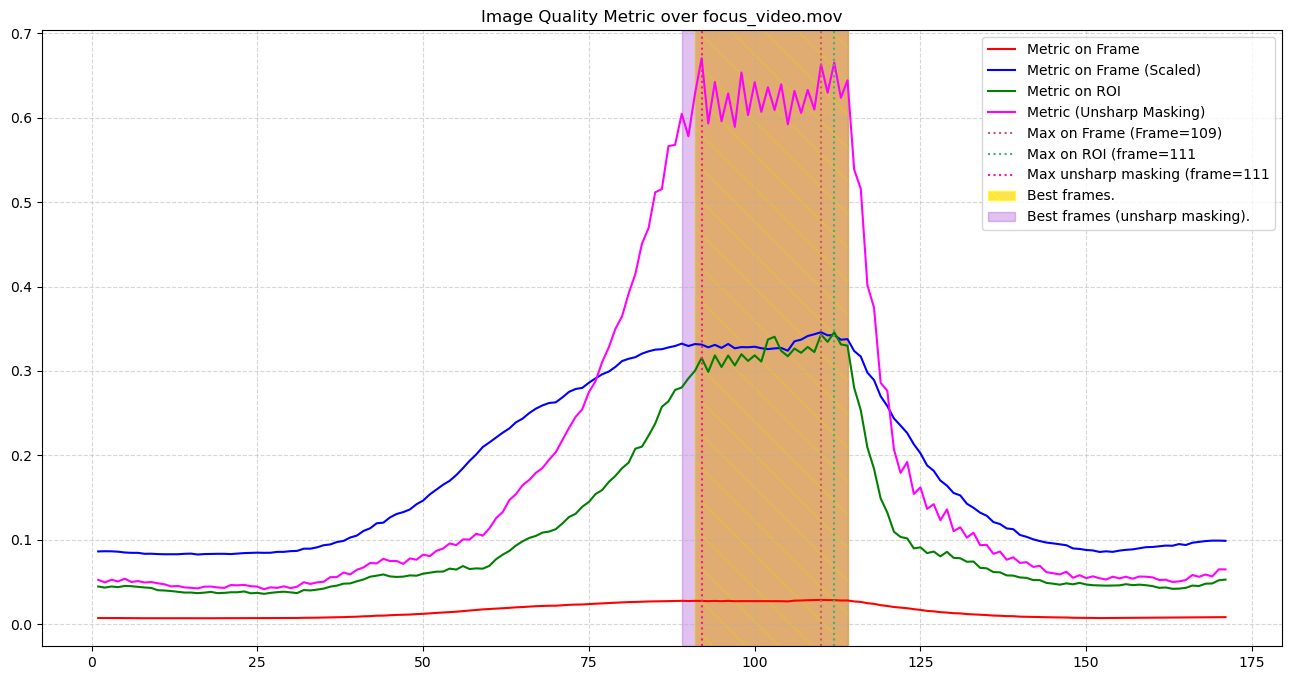

In [13]:
# Repeat graph with best frames obtained via unsharp masking.
fig, ax = plt.subplots(figsize=(16, 8))

# Curves
x = np.arange(1, len(metric)+1)
ax.plot(x, metric, color='r', label='Metric on Frame')
ax.plot(x, np.array(metric)*np.max(metric_roi)/np.max(metric), color='b', label='Metric on Frame (Scaled)')
ax.plot(x, metric_roi, color='g', label='Metric on ROI')
ax.plot(x, metric_um, color='magenta', label='Metric (Unsharp Masking)')

# Max
ax.axvline(x[np.argmax(metric)], color='indianred', linestyle=":", label=f"Max on Frame (Frame={np.argmax(metric)})")
ax.axvline(x[np.argmax(metric_roi)], color='mediumseagreen', linestyle=":", label=f"Max on ROI (frame={np.argmax(metric_roi)}")
ax.axvline(x[np.argmax(metric_um)], color='deeppink', linestyle=":", label=f"Max unsharp masking (frame={np.argmax(metric_roi)}")

# Best frames.
ax.axvspan(best_frames[0]+1, best_frames[-1]+1, facecolor='gold', hatch='\\', edgecolor='yellow', alpha=0.7, label='Best frames.')
ax.axvspan(best_frames_um[0]+1, best_frames_um[-1]+1, color='darkorchid', alpha=0.3, label='Best frames (unsharp masking).')


ax.set_title(f'Image Quality Metric over {vid_path}')
ax.grid(zorder=0, linestyle='--', alpha=0.5)
ax.legend()

plt.show()

We see that the best frame sequence is slightly expanded towards earlier frames. This should make sense, since the decrease in the metric is quite sharp for frames immediately after our last best frame, but it's much smoother towards earlier frames. As the graph shows, applying unsharp masking not only strengthens the overall values of the metric on the focused regions but it also dampens its value on the regions that are not focused. It's reasonable to expect that the best frame region will get expanded as a result of this effect. Interestingly, the maximum in the metric got shifted quite a bit, as well.

If anything, applying unsharp masking serves as a confirmation that the previous estimate was decent, even if a better method like a matrix-like ROI (as discussed during the course) would be a better estimator.